# 03 - Archetypes and Clustering

NBA 2K26 already assigns each player its own `archetype` field (e.g. "2-Way 3-Level Shot
Creator", "Crafty Sharpshooter"), but that field is a *designer-authored* label built by
combining modular descriptor tokens (shooting profile, slashing/finishing style, playmaking,
defense) - it is not derived from clustering the attribute data itself. This notebook asks a
different question: if we ignore `archetype` (and `position`) entirely and let the ~35 granular
2K26 attribute ratings (not the six `cat_*` category rollups, which are themselves just
aggregates of these) speak for themselves via PCA + KMeans, what data-driven archetypes fall
out - and how much do they agree with, or diverge from, 2K's own labels?

Uses `data/processed/players_merged.csv` (377 players) restricted to the subset with complete
attribute data, in the same spirit as `fifa-analysis`'s `03_clustering.ipynb`.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv")
print(f"{len(df):,} players, {df.shape[1]} columns")

377 players, 117 columns


## Choosing the clustering features

The dataset has ~40 sub-attributes underneath 2K's six `cat_*` category rollups
(`cat_outside_scoring`, `cat_athleticism`, `cat_inside_scoring`, `cat_playmaking`, `cat_defense`,
`cat_rebounding`). We cluster on the granular attributes themselves rather than the six
category rollups, so the resulting structure isn't just "recovering" 2K's own six-way
aggregation. `potential` (a separate numeric field, mostly populated only for younger players -
204 of 377 missing) and `potential_grade` (a messy mix of letter grades and raw numbers) are
excluded as they aren't play-style attributes. `overall_durability`, `hustle`, `stamina`, and a
handful of others are effort/durability ratings rather than skill per se, but are included since
they're still part of 2K's genuine attribute sheet and do carry play-style signal (e.g. bigs
consistently run hotter on hustle/durability than high-usage wings).

In [2]:
ATTRS = [
    "agility", "ball_handle", "block", "close_shot", "defensive_consistency",
    "defensive_rebound", "draw_foul", "driving_dunk", "free_throw", "hands",
    "help_defense_iq", "hustle", "interior_defense", "layup", "mid_range_shot",
    "offensive_consistency", "offensive_rebound", "overall_durability",
    "pass_accuracy", "pass_iq", "pass_perception", "pass_vision", "perimeter_defense",
    "post_control", "post_fade", "post_hook", "shot_iq", "speed", "speed_with_ball",
    "stamina", "standing_dunk", "steal", "strength", "three_point_shot", "vertical",
]
print(f"{len(ATTRS)} granular attributes used for clustering")

cl = df.dropna(subset=ATTRS).copy()
print(f"{len(cl)} players with complete attribute data ({len(df) - len(cl)} excluded, "
      f"mostly players whose archived page was scraped before badges/attributes fully loaded)")
cl[ATTRS].describe().round(1).T.head(10)

35 granular attributes used for clustering
344 players with complete attribute data (33 excluded, mostly players whose archived page was scraped before badges/attributes fully loaded)


,count,mean,std,min,25%,50%,75%,max
agility,344.0,74.7,11.8,33.0,68.0,77.0,84.0,95.0
ball_handle,344.0,69.9,14.8,30.0,60.8,72.0,79.2,99.0
block,344.0,57.0,15.3,25.0,47.0,55.0,68.0,99.0
close_shot,344.0,82.8,10.0,54.0,76.0,83.5,91.0,99.0
defensive_consistency,344.0,59.9,16.6,30.0,45.0,60.0,75.0,98.0
defensive_rebound,344.0,61.6,14.1,34.0,50.0,60.0,70.0,95.0
draw_foul,344.0,57.0,17.1,25.0,43.0,53.5,68.0,98.0
driving_dunk,344.0,70.1,14.5,25.0,65.0,75.0,80.0,97.0
free_throw,344.0,75.7,9.9,40.0,70.0,77.0,83.0,94.0
hands,344.0,83.2,8.8,59.0,78.0,82.0,90.0,98.0


## Standardize + PCA

Attributes are all on 2K's 25-99 scale but with different spreads across the player pool
(e.g. `three_point_shot` varies far more across players than `hustle`, where nearly everyone
sits 75+), so we standardize before PCA/KMeans to keep any one attribute from dominating the
distance metric purely due to its variance.

In [3]:
scaler = StandardScaler()
X = cl[ATTRS].values
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_for_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Components needed for 90% cumulative variance: {n_for_90} (of {len(ATTRS)})")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
cl["pca1"] = X_pca[:, 0]
cl["pca2"] = X_pca[:, 1]

print(f"PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"cumulative(2)={pca.explained_variance_ratio_[:2].sum():.1%}")

loadings = pd.DataFrame(pca.components_.T, index=ATTRS, columns=["PC1", "PC2"])
loadings.sort_values("PC1").round(2)

Components needed for 90% cumulative variance: 17 (of 35)
PC1=30.6%, PC2=19.5%, cumulative(2)=50.0%


,PC1,PC2
offensive_rebound,-0.25,0.07
standing_dunk,-0.24,0.16
defensive_rebound,-0.20,0.18
post_hook,-0.20,0.24
block,-0.19,0.13
interior_defense,-0.19,0.23
strength,-0.19,0.21
post_control,-0.17,0.26
post_fade,-0.12,0.27
driving_dunk,-0.08,0.14


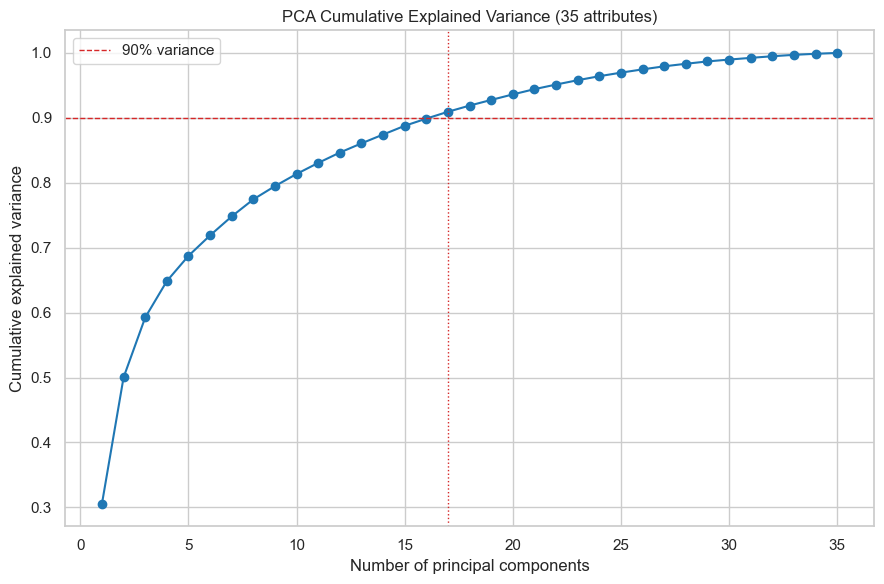

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, len(ATTRS) + 1), cum_var, marker="o", color="#1f77b4")
ax.axhline(0.90, color="#d62728", ls="--", lw=1, label="90% variance")
ax.axvline(n_for_90, color="#d62728", ls=":", lw=1)
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA Cumulative Explained Variance (35 attributes)")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** with 35 correlated attributes, no single 2D projection captures the bulk of
the variance the way FIFA's six independent category ratings did - it takes a double-digit
number of components to reach 90% cumulative variance, reflecting that 2K26's attribute sheet
has real multidimensional structure (shooting, ball skills, defense, post play, and athleticism
are all fairly distinct axes rather than all loading onto one or two broad factors). Still, PC1
loads positively on almost every perimeter skill attribute (ball handle, pass vision, three
point shot, speed with ball) and negatively on post-game attributes (post control/fade/hook,
standing dunk) - it reads as a "perimeter skill vs. traditional big man" axis rather than a
generic "how good is this player" axis, since KMeans below is run on the full standardized
35-dimension space (not just these first two components) and PC1/PC2 are used only for the 2D
visualization.

## Choosing k

In [5]:
results = []
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_, random_state=RANDOM_STATE)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette
0,3,8150.184630,0.184364
1,4,7575.934658,0.117783
2,5,7139.649006,0.116869
3,6,6790.257523,0.113931
4,7,6497.796790,0.117075
5,8,6287.839521,0.108725
6,9,6103.425438,0.096777
7,10,5976.678525,0.093172


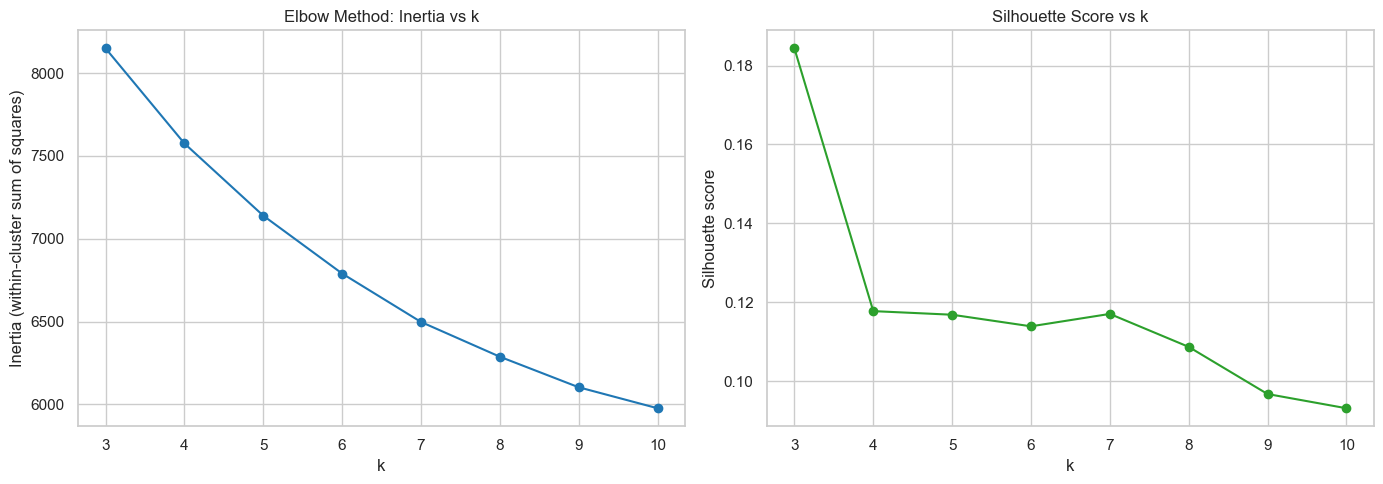

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["k"], results_df["inertia"], marker="o", color="#1f77b4")
axes[0].set_title("Elbow Method: Inertia vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")

axes[1].plot(results_df["k"], results_df["silhouette"], marker="o", color="#2ca02c")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

**Takeaway:** silhouette score decays roughly monotonically from k=3 with only a
shallow, noisy shoulder further out - unsurprising for a continuous, correlated attribute space
where "true" position/role boundaries are themselves fuzzy (plenty of players are legitimate
hybrids). As with the FIFA project, we favor **interpretability over the single tightest
mathematical partition** and pick **k=7**: the elbow curve has mostly flattened by then, and as
shown below it produces seven clusters that are each easy to label with a clear,
basketball-sensible attribute profile and a recognizable list of representative players -
smaller k (e.g. 3-4) collapses distinct groups like "skilled stretch bigs" and "rim-running
bigs" together, which lose exactly the kind of nuance a 35-attribute sheet is meant to capture.

In [7]:
K = 7
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
cl["cluster"] = kmeans.labels_

cluster_profile = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=ATTRS)
cluster_profile["count"] = cl["cluster"].value_counts().sort_index().values
cluster_profile.round(1).T

,0,1,2,3,4,5,6
agility,79.4,84.5,72.2,83.1,55.2,79.3,63.7
ball_handle,76.2,77.1,65.6,87.0,50.4,78.5,47.4
block,66.4,56.7,56.0,47.9,70.8,43.9,77.6
close_shot,91.8,81.3,77.6,88.3,89.7,81.2,81.8
defensive_consistency,79.9,76.9,51.6,62.7,60.5,47.6,61.8
defensive_rebound,79.6,54.6,60.7,55.8,76.9,49.4,79.8
draw_foul,86.6,52.4,49.6,79.4,58.5,52.1,44.5
driving_dunk,83.4,69.8,74.3,70.6,69.8,57.5,76.3
free_throw,76.1,76.6,72.5,84.8,74.6,80.3,61.5
hands,94.9,85.2,77.8,91.8,84.4,81.2,78.2


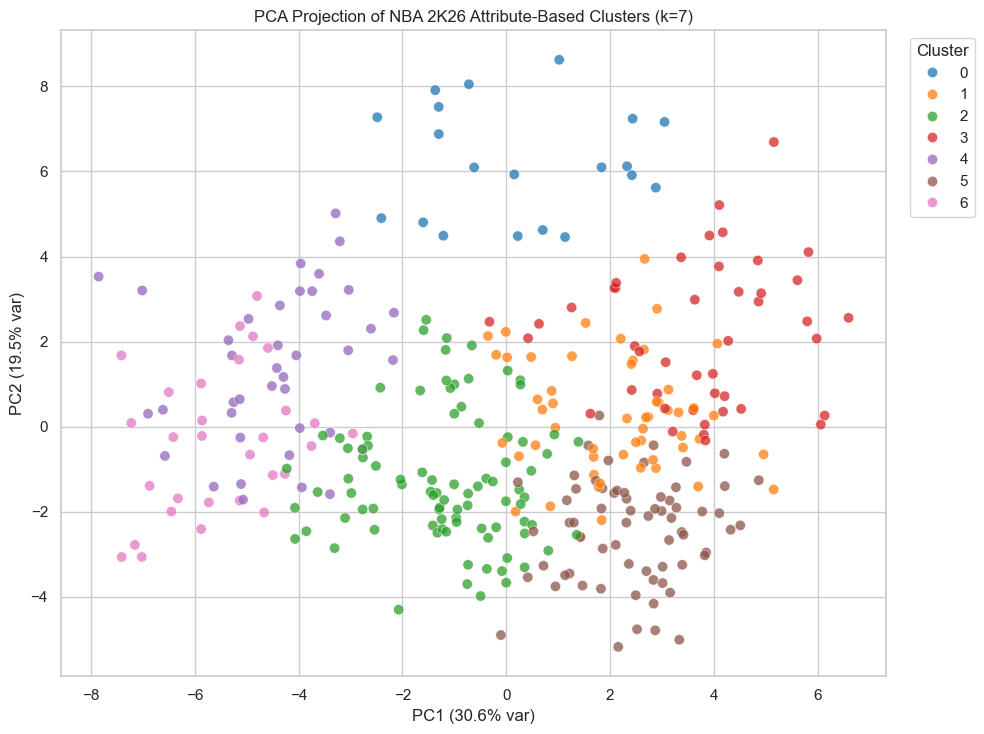

In [8]:
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.scatterplot(
    data=cl, x="pca1", y="pca2", hue="cluster", palette="tab10",
    alpha=0.75, s=55, edgecolor="white", linewidth=0.4, ax=ax,
)
ax.set_title("PCA Projection of NBA 2K26 Attribute-Based Clusters (k=7)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
for c in sorted(cl["cluster"].unique()):
    top = cl[cl["cluster"] == c].sort_values("overall", ascending=False).head(6)
    print(f"Cluster {c} (n={sum(cl['cluster'] == c)}): {', '.join(top['name'])}")

Cluster 0 (n=20): Nikola Jokic, Giannis Antetokounmpo, Luka Doncic, Anthony Davis, Jayson Tatum, Victor Wembanyama
Cluster 1 (n=55): Amen Thompson, Jrue Holiday, Mikal Bridges, Norman Powell, Tari Eason, Dillon Brooks
Cluster 2 (n=89): Alexandre Sarr, Michael Porter Jr., Jabari Smith Jr., Jalen Johnson, Keegan Murray, Rui Hachimura
Cluster 3 (n=44): Shai Gilgeous-Alexander, Stephen Curry, Anthony Edwards, Donovan Mitchell, Jalen Brunson, Cade Cunningham
Cluster 4 (n=39): Ivica Zubac, Kristaps Porzingis, Domantas Sabonis, Myles Turner, Lauri Markkanen, Deandre Ayton
Cluster 5 (n=66): Jordan Poole, Bogdan Bogdanovic, Malik Monk, Isaiah Joe, Tre Jones, Dennis Schroder
Cluster 6 (n=31): Jalen Duren, Robert Williams III, Daniel Gafford, Dereck Lively II, Clint Capela, Yves Missi


## Labeling the clusters

Inspecting each cluster's mean attribute profile and highest-`overall` representative players
suggests seven clear, nameable archetypes:

| Cluster | Archetype | Profile |
|---|---|---|
| 0 | **Elite Two-Way Superstars** | Highest attributes almost across the board (offense, defense, playmaking, rebounding all elite); smallest cluster - Jokic, Giannis, Doncic, Davis, Tatum, Wembanyama |
| 1 | **3-and-D Connectors** | High perimeter defense/steal/athleticism, modest shot creation and post game; glue-guy wings and combo forwards - Amen Thompson, Jrue Holiday, Mikal Bridges, Dillon Brooks |
| 2 | **Do-It-All Forwards** | Largest cluster; moderate-to-good across most categories without a standout carrying skill - Alexandre Sarr, Michael Porter Jr., Jabari Smith Jr., Jalen Johnson |
| 3 | **Shot-Creating Lead Guards** | Highest ball handle/pass vision/speed-with-ball/shot IQ; the primary shot-creators - Shai Gilgeous-Alexander, Stephen Curry, Anthony Edwards, Jalen Brunson |
| 4 | **Skilled Post Bigs** | Highest post control/fade/hook and standing dunk, strong defensive rebounding; traditional back-to-the-basket size - Zubac, Porzingis, Sabonis, Myles Turner |
| 5 | **Movement Shooters / Bench Guards** | Lowest interior defense/post game/steal, solid three-point shot and speed; low-usage perimeter specialists - Jordan Poole, Bogdan Bogdanovic, Malik Monk |
| 6 | **Rim-Running Bigs** | Highest block/offensive rebound/standing dunk, lowest three-point/mid-range shot and pass vision - Jalen Duren, Robert Williams III, Daniel Gafford, Clint Capela |

Cluster 0 is notable for cutting *across* every position group below - it's really an "elite
regardless of role" cluster rather than a positional one, echoing the FIFA project's analogous
"Elite All-Rounder" finding.

## How do the clusters map onto position?

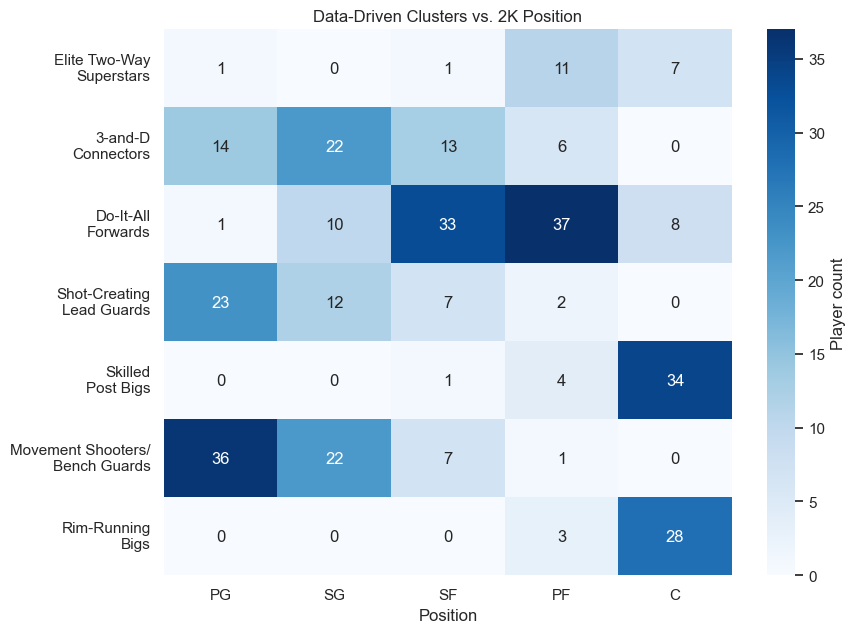

position,PG,SG,SF,PF,C
cluster_label,,,,,
Elite Two-Way\nSuperstars,1,0,1,11,7
3-and-D\nConnectors,14,22,13,6,0
Do-It-All\nForwards,1,10,33,37,8
Shot-Creating\nLead Guards,23,12,7,2,0
Skilled\nPost Bigs,0,0,1,4,34
Movement Shooters/\nBench Guards,36,22,7,1,0
Rim-Running\nBigs,0,0,0,3,28


In [10]:
LABELS = {
    0: "Elite Two-Way\nSuperstars", 1: "3-and-D\nConnectors", 2: "Do-It-All\nForwards",
    3: "Shot-Creating\nLead Guards", 4: "Skilled\nPost Bigs",
    5: "Movement Shooters/\nBench Guards", 6: "Rim-Running\nBigs",
}
cl["cluster_label"] = cl["cluster"].map(LABELS)

pos_order = ["PG", "SG", "SF", "PF", "C"]
ct_pos = pd.crosstab(cl["cluster_label"], cl["position"])[pos_order]
ct_pos = ct_pos.reindex([LABELS[c] for c in range(K)])

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(ct_pos, annot=True, fmt="d", cmap="Blues", ax=ax, cbar_kws={"label": "Player count"})
ax.set_title("Data-Driven Clusters vs. 2K Position")
ax.set_xlabel("Position")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

ct_pos

**Takeaway:** the clusters recover position structure to a real but imperfect degree.
"Skilled Post Bigs" and "Rim-Running Bigs" are overwhelmingly centers/power forwards, and
"Shot-Creating Lead Guards" skews heavily toward point/shooting guards, confirming the attribute
data alone reconstructs a recognizable positional signal. But "Do-It-All Forwards" and "3-and-D
Connectors" both spread across three-plus positions, and "Elite Two-Way Superstars" spans PG
through C entirely - modern NBA positional versatility (point-forwards, small-ball
fives, do-everything wings) means several of these attribute-driven groups are genuinely
cross-positional archetypes, not just a relabeled position column.

## How do the clusters compare to 2K's own `archetype` field?

2K assigns each player a highly bespoke `archetype` string built by combining modular
descriptor tokens (an offensive-skill token, a slashing/finishing token, a playmaking token, an
optional "2-Way" defensive prefix, etc.) - e.g. "2-Way 3-Level Shot Creator", "Crafty
Sharpshooter". This makes it, as noted in notebook 01, **highly fragmented**: 172 distinct
labels across only 344 clustered players, so a direct label-for-label crosstab against 7
clusters would be mostly empty cells. Instead we tag each archetype string for the presence of
six broad *tokens* it's built from (a label can match more than one token, since they're
compound), and compare the token-presence rate across our seven data-driven clusters -
a fairer test of whether 2K's own labeling vocabulary agrees with the attribute-driven
groupings.

In [11]:
TOKENS = {
    "2-Way (defense-conscious label)": r"2-Way",
    "Shooting (3PT/Sniper/Sharpshoot/Stretch)": r"3PT|Sniper|Sharpshoot|Stretch",
    "Slashing/Rim (Blow-By/Rim/Dunk/Finisher/High-Flying/Lob)": r"Blow-By|Rim|Dunk|Finisher|High-Flying|Lob|Aerial",
    "Playmaking (Playmak/Creator/Dime/Table Setter/Floor General)": r"Playmak|Creator|Dim(?:e|ing)|Table Setter|Floor General",
    "Post/Paint/Boards (Post/Paint/Board/Crasher/Rebound)": r"Post|Paint|Board|Crasher|Rebound",
    "Defense-first (Stopper/Lock/Menace/Eraser/Anchor/Defen/Hawk)": r"Stopper|Lock|Menace|Eraser|Anchor|Defen|Hawk|Erasing",
}

arche = cl["archetype"].fillna("")
for label, pat in TOKENS.items():
    cl[label] = arche.str.contains(pat, regex=True)

print(f"{(cl['archetype'].notna()).sum()} of {len(cl)} clustered players have a listed archetype "
      f"({cl['archetype'].nunique()} distinct labels among them)")

token_rate = cl.groupby("cluster_label")[list(TOKENS.keys())].mean().reindex(
    [LABELS[c] for c in range(K)]
) * 100
token_rate.round(1)

273 of 344 clustered players have a listed archetype (153 distinct labels among them)


,2-Way (defense-conscious label),Shooting (3PT/Sniper/Sharpshoot/Stretch),Slashing/Rim (Blow-By/Rim/Dunk/Finisher/High-Flying/Lob),Playmaking (Playmak/Creator/Dime/Table Setter/Floor General),Post/Paint/Boards (Post/Paint/Board/Crasher/Rebound),Defense-first (Stopper/Lock/Menace/Eraser/Anchor/Defen/Hawk)
cluster_label,,,,,,
Elite Two-Way\nSuperstars,45.0,5.0,5.0,15.0,20.0,5.0
3-and-D\nConnectors,38.2,10.9,12.7,25.5,0.0,12.7
Do-It-All\nForwards,2.2,29.2,16.9,3.4,4.5,7.9
Shot-Creating\nLead Guards,15.9,2.3,9.1,34.1,2.3,4.5
Skilled\nPost Bigs,17.9,12.8,2.6,0.0,30.8,12.8
Movement Shooters/\nBench Guards,3.0,22.7,9.1,28.8,0.0,4.5
Rim-Running\nBigs,9.7,0.0,32.3,0.0,22.6,16.1


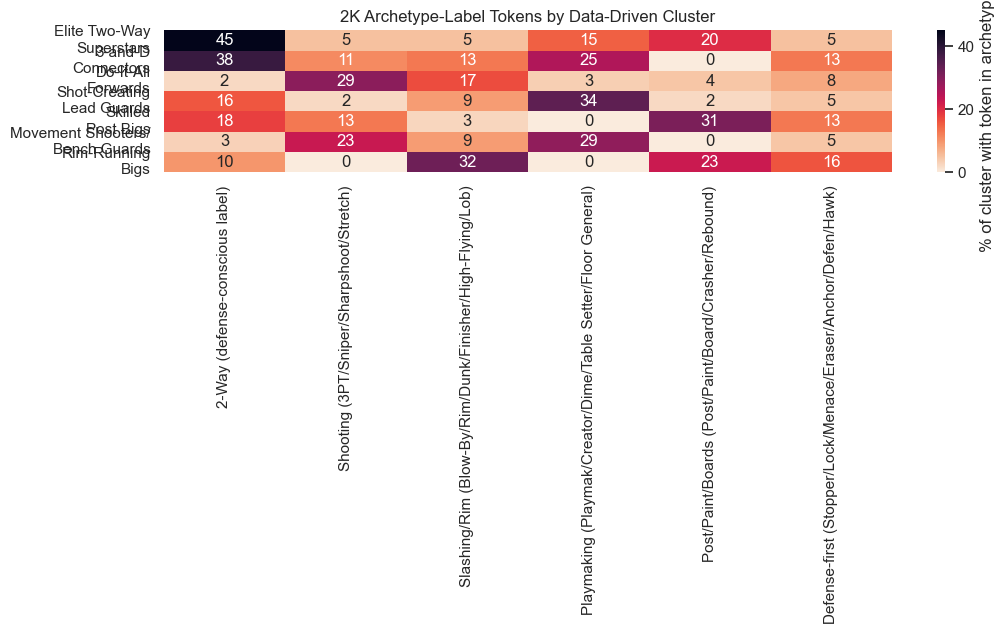

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(token_rate, annot=True, fmt=".0f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "% of cluster with token in archetype label"})
ax.set_title("2K Archetype-Label Tokens by Data-Driven Cluster")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Takeaway:** there's real, sensible agreement in places - "Shot-Creating Lead Guards"
and "Movement Shooters/Bench Guards" both carry a Shooting token far more often than "Rim-Running
Bigs" or "Skilled Post Bigs" do, and the Post/Paint/Boards token is heavily concentrated in the
two big-man clusters as expected. But the two label vocabularies diverge in an interesting way
at the extremes: "Elite Two-Way Superstars" (Jokic/Giannis/Doncic-caliber players) don't carry
the highest 2-Way token rate - 2K reserves the literal "2-Way" prefix for defense-plus-offense
*role* labels applied more broadly across several clusters (including role-player wings), while
truly elite two-way superstars often get an entirely bespoke, non-formulaic label (e.g.
"Triple-Double Threat") that doesn't use the standard token vocabulary at all. This is a
genuinely different signal than the clustering: 2K's archetype system is designed to describe
*how a player scores and defends stylistically* (a game-design/gameplay-mechanics lens), while
our attribute clusters group players by *overall statistical similarity across the full
attribute sheet* (a scouting/statistical lens) - the two mostly agree on shooting/big-man
identity but diverge on how they characterize all-around excellence.

## Summary

- 2K26's ~40 sub-attributes have real multidimensional structure - it takes well over a
  handful of principal components to reach 90% cumulative variance, unlike FIFA's six broad
  category ratings, which compress overwhelmingly into two components.
- A k=7 KMeans solution on the standardized attribute space (chosen for interpretability, since
  silhouette score itself favors far smaller k) produces seven clean, nameable archetypes:
  Elite Two-Way Superstars, 3-and-D Connectors, Do-It-All Forwards, Shot-Creating Lead Guards,
  Skilled Post Bigs, Movement Shooters/Bench Guards, and Rim-Running Bigs.
- The clusters recover real positional structure for bigs and lead guards, but several clusters
  (most notably "Elite Two-Way Superstars") cut across all five traditional positions -
  consistent with modern NBA positional versatility rather than being a relabeled position
  column.
- Comparing cluster membership against 2K's own bespoke `archetype` labels (via token tags,
  since the raw field is too fragmented - 172 distinct labels - for a direct crosstab) shows
  real agreement on shooting- and post-oriented identity, but a genuine divergence at the top:
  the game's literal "2-Way" labeling convention doesn't concentrate in the statistically most
  elite/all-around cluster the way a naive reading might expect, suggesting 2K's archetype
  system is tuned to describe playstyle/gameplay mechanics rather than overall statistical
  similarity.